# Passenger Vehicle Supply & Demand Analysis
## Time Series Analysis of U.S. Vehicle Sales and Manufacturing Orders (2000-2024)

### Project Overview
This analysis explores vehicle supply and consumer demand for passenger vehicles in the U.S. between January 2000 and July 2024.

### Research Questions:
1. Are there specific characteristics of the time series representing vehicle usage that contribute most to the predictability of the time series?
2. Is there any relationship between the trends of vehicle supply & consumer demand?
3. Are there any external or exogenous factors that help in predicting vehicle sales?

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Data Loading and Preprocessing

In [2]:
# Load the data
df = pd.read_csv('VehicleData-1.csv')

# Convert DATE to datetime
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.set_index('DATE')

# Rename columns for clarity
df.columns = ['Total_Sales', 'New_Orders']

# Display basic information
print("Dataset Shape:", df.shape)
print("\nDate Range:", df.index.min(), "to", df.index.max())
print("\nFirst few rows:")
print(df.head())
print("\nLast few rows:")
print(df.tail())
print("\nBasic Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (295, 2)

Date Range: 2000-01-01 00:00:00 to 2024-07-01 00:00:00

First few rows:
            Total_Sales  New_Orders
DATE                               
2000-01-01       18.635       43668
2000-02-01       19.401       39808
2000-03-01       18.343       40749
2000-04-01       17.939       40644
2000-05-01       17.943       38730

Last few rows:
            Total_Sales  New_Orders
DATE                               
2024-03-01       15.929       63531
2024-04-01       16.345       64455
2024-05-01       16.480       64445
2024-06-01       15.629       63995
2024-07-01       16.348       62339

Basic Statistics:
       Total_Sales    New_Orders
count   295.000000    295.000000
mean     15.965292  45440.576271
std       2.219743   9751.191093
min       8.834000  18900.000000
25%      15.037000  39348.000000
50%      16.634000  43297.000000
75%      17.515000  53753.000000
max      22.055000  64455.000000

Missing Values:
Total_Sales    0
New_Orders     0
dtype: int64


## 2. Exploratory Data Analysis

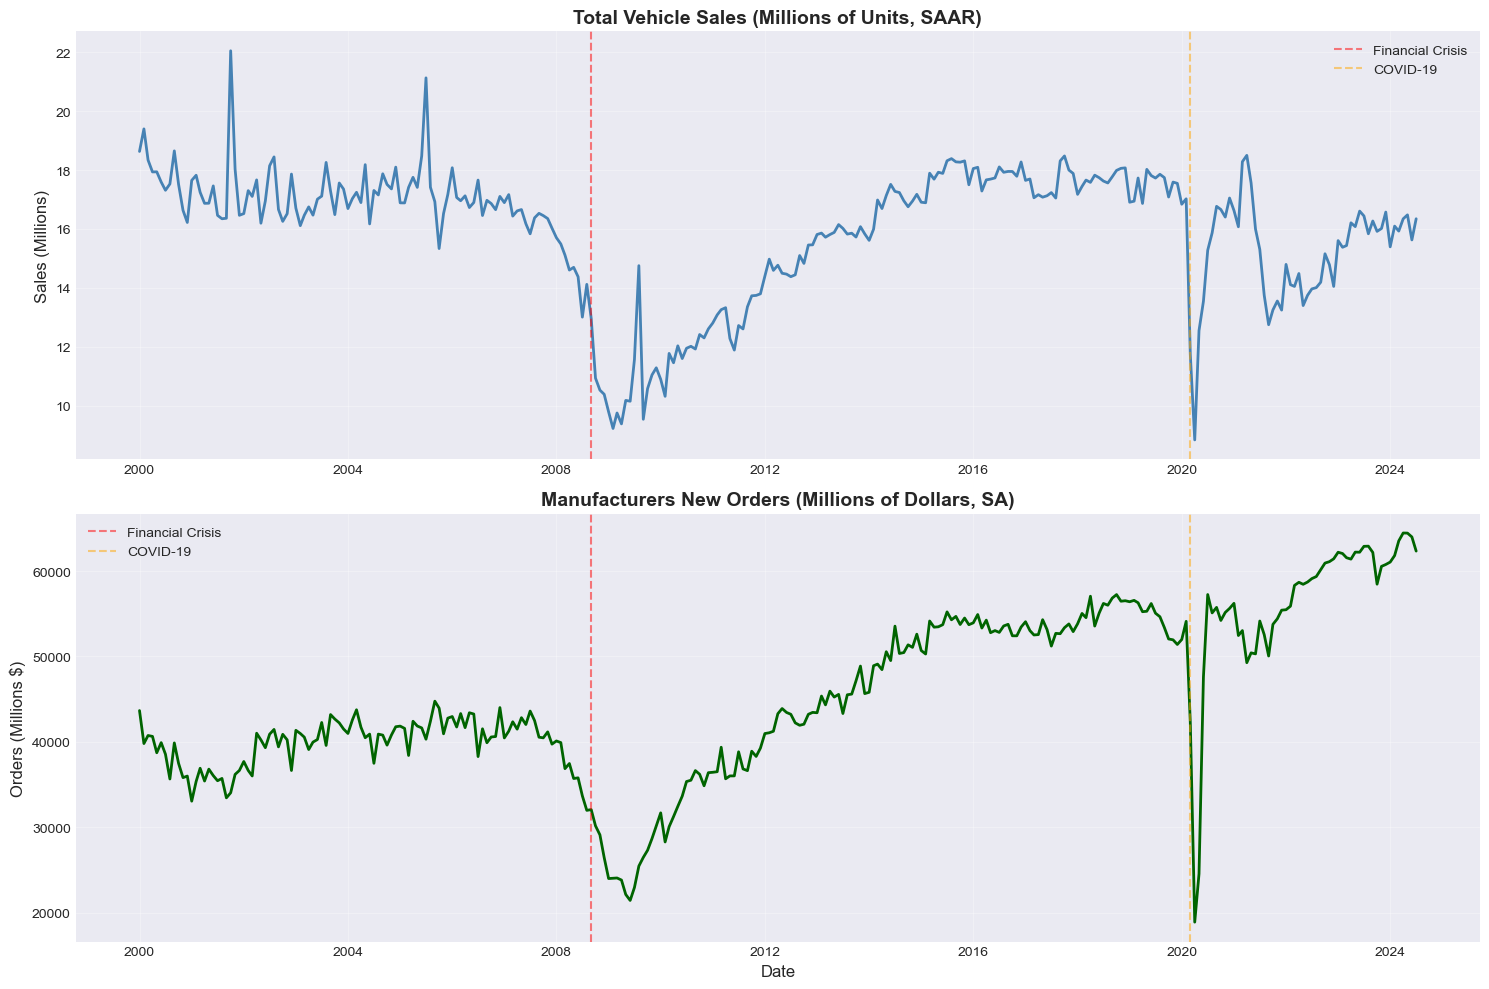

In [3]:
# Time series plots
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Total Sales
axes[0].plot(df.index, df['Total_Sales'], linewidth=2, color='steelblue')
axes[0].set_title('Total Vehicle Sales (Millions of Units, SAAR)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales (Millions)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(pd.Timestamp('2008-09-01'), color='red', linestyle='--', alpha=0.5, label='Financial Crisis')
axes[0].axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle='--', alpha=0.5, label='COVID-19')
axes[0].legend()

# New Orders
axes[1].plot(df.index, df['New_Orders'], linewidth=2, color='darkgreen')
axes[1].set_title('Manufacturers New Orders (Millions of Dollars, SA)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Orders (Millions $)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(pd.Timestamp('2008-09-01'), color='red', linestyle='--', alpha=0.5, label='Financial Crisis')
axes[1].axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle='--', alpha=0.5, label='COVID-19')
axes[1].legend()

plt.tight_layout()
plt.savefig('time_series_overview.png', dpi=300, bbox_inches='tight')
plt.show()